In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
sys.path.append("/root/limlab01/kaistai/25DFT/QHFlow/src")
from dft_process.dft_process_utils import *

INFO     [dft_process_utils.py:32] >> Source path: /root/limlab01/kaistai/25DFT/QHFlow/src

INFO     [dft_process_utils.py:62] >> Root path: /root/limlab01/kaistai/25DFT/QHFlow

In [2]:
import md.scflow_calculator

In [3]:
md17_experiment = MD17Experiment(data_index=1)
md17_experiment.set_model_path()

# cur_ckpt = "/root/25DFT/QHFlow/src/outputs/malondialdehyde/QHFlow_so2_v5_1_small_v2-malondialdehyde/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"
cur_ckpt = "/root/25DFT/QHFlow/src/outputs/malondialdehyde/QHFlow_so2_v5_1_middle-malondialdehyde/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"
# cur_ckpt = "/root/25DFT/QHFlow/src/outputs/rmd-aspirin/QHFlow_so2_v5_1_middle-rmd-aspirin/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"
cur_ckpt = "/root/25DFT/QHFlow/src/outputs/ethanol/QHFlow_so2_v5_1_middle-ethanol/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"

INFO     [setup.py:66] >> Seed: 0

Seed set to 0


ConfigNamespace({'dataset_name': 'water', 'num_train': 500, 'num_valid': 500, 'density_loss': 0.01, 'max_radius': 15.0, 'batch_size': 16, 'train_batch_size': 16, 'valid_batch_size': 16, 'test_batch_size': 16})


INFO     [dft_process_utils.py:202] >> [!] conf.dataset.dataset_name: ethanol

md17
ethanol
MD17_DFT(30000)


In [4]:
sample_ethanol = [
    (6,  [-0.28630036, -0.47787276,  0.03603168]),  # C
    (6,  [-0.92012881,  0.96245698,  0.23729976]),  # C
    (8,  [ 1.10116376, -0.40535771, -0.20377836]),  # O
    (1,  [-0.49412140, -1.15617614,  0.94202625]),  # H
    (1,  [-0.80417700, -0.91072034, -0.80315132]),  # H
    (1,  [-1.91334152,  0.70271240,  0.63912332]),  # H
    (1,  [-0.36050056,  1.60555901,  0.92692388]),  # H
    (1,  [-0.93001164,  1.37368891, -0.73671183]),  # H
    (1,  [ 1.39790227, -0.95652028, -0.99060288]),  # H
]
sample_ethanol_atoms = [a[0] for a in sample_ethanol]
sample_ethanol_coords = [a[1] for a in sample_ethanol]
sample_ethanol_atoms, sample_ethanol_coords

([6, 6, 8, 1, 1, 1, 1, 1, 1],
 [[-0.28630036, -0.47787276, 0.03603168],
  [-0.92012881, 0.96245698, 0.23729976],
  [1.10116376, -0.40535771, -0.20377836],
  [-0.4941214, -1.15617614, 0.94202625],
  [-0.804177, -0.91072034, -0.80315132],
  [-1.91334152, 0.7027124, 0.63912332],
  [-0.36050056, 1.60555901, 0.92692388],
  [-0.93001164, 1.37368891, -0.73671183],
  [1.39790227, -0.95652028, -0.99060288]])

In [5]:
sccalculator = md.scflow_calculator.SCFlowRKSCalculator()

In [6]:
sccalculator.set_model(cur_ckpt)

INFO     [__init__.py:100] >> model_args: {'in_node_features': 1, 'sh_lmax': 4, 'hidden_size': 128,                
         'bottle_hidden_size': 32, 'num_gnn_layers': 3, 'max_radius': 15, 'num_nodes': 10, 'radius_embed_dim': 16, 
         'max_T': 15, 'use_block_S': False, 'use_block_H': False, 'ham_dim': 24, 'ham_hidden': 288, 'dataset_type':
         'qh9', 'num_ham_gnn_layers': 2}

Setting device to cuda


INFO     [base_module.py:128] >> use_init_hamiltonian: False

INFO     [base_module.py:129] >> use_init_hamiltonian_residue: True

INFO     [base_module.py:130] >> ema_start_epoch: -1

INFO     [base_module.py:131] >> qh9: False

INFO     [base_module.py:132] >> test_mode: test

INFO     [flow_module.py:211] >> init_p0_type: expand

model trained on dataset:  ethanol
ode_steps: 1


In [7]:
sample = md17_experiment.dataset[1]
sample.energy

tensor([-154.7023])

In [8]:
ase_atoms = md.scflow_calculator.QHData_to_atoms(sample, unit="bohr")

In [9]:
ase_atoms

Atoms(symbols='C2OH6', pbc=True, cell=[1.0, 1.0, 1.0])

In [10]:
properties = ["energy", "forces"]
system_changes = ["positions"]
sccalculator.calculate(ase_atoms, properties, system_changes, units="ang", model_length_unit="bohr")

(-154.7025151797294,
 array([[ 0.0523931 , -0.00517096,  0.01386692],
        [-0.04991483,  0.01081311,  0.02502159],
        [-0.0278159 ,  0.03568867,  0.03256439],
        [ 0.00485118,  0.01052474, -0.02841165],
        [-0.00383468, -0.01906049,  0.00581736],
        [ 0.01174012, -0.01142272, -0.01948775],
        [ 0.01349015, -0.00545967, -0.00216176],
        [ 0.00086956, -0.002466  , -0.0007429 ],
        [-0.00220744, -0.01349788, -0.02657959]]))

In [11]:
sccalculator.ovlp.shape

(72, 72)

In [12]:
rkscalculator = md.scflow_calculator.RKSCalculator()
rkscalculator.calculate(ase_atoms, properties, system_changes, units="ang")
rkscalculator.results["energy"], rkscalculator.results["forces"]


(-154.70227790042603,
 array([[ 0.05231548, -0.00513741,  0.01389609],
        [-0.04989778,  0.01081677,  0.02505437],
        [-0.02742003,  0.03575036,  0.03268381],
        [ 0.00485447,  0.01050121, -0.02839209],
        [-0.00381367, -0.01907195,  0.00576225],
        [ 0.01177119, -0.01143027, -0.01952918],
        [ 0.01351286, -0.00548659, -0.0021295 ],
        [ 0.00087142, -0.00242822, -0.00074041],
        [-0.00216814, -0.01349152, -0.02660532]]))

Using O index 2, H index 8, initial d=1.005 Å


INFO     [__init__.py:100] >> model_args: {'in_node_features': 1, 'sh_lmax': 4, 'hidden_size': 128,                
         'bottle_hidden_size': 32, 'num_gnn_layers': 3, 'max_radius': 15, 'num_nodes': 10, 'radius_embed_dim': 16, 
         'max_T': 15, 'use_block_S': False, 'use_block_H': False, 'ham_dim': 24, 'ham_hidden': 288, 'dataset_type':
         'qh9', 'num_ham_gnn_layers': 2}

Setting device to cuda


INFO     [base_module.py:128] >> use_init_hamiltonian: False

INFO     [base_module.py:129] >> use_init_hamiltonian_residue: True

INFO     [base_module.py:130] >> ema_start_epoch: -1

INFO     [base_module.py:131] >> qh9: False

INFO     [base_module.py:132] >> test_mode: test

INFO     [flow_module.py:211] >> init_p0_type: expand

model trained on dataset:  ethanol
ode_steps: 1
Running model: scflow
0.01
246.20907270719044
0.08666666666666666
-122.6607619436961
0.16333333333333333
-141.85348628012525
0.24
-148.10474367322595
0.31666666666666665
-151.03064310632647
0.3933333333333333
-152.5819055143403
0.47
-153.4624342327583
0.5466666666666666
-153.99929636141027
0.6233333333333333
-154.33187640504173
0.7
-154.5271288508988
0.7766666666666666
-154.63311287709354
0.8533333333333333
-154.69124712190563
0.9299999999999999
-154.70915738204195
1.0066666666666666
-154.7096541631865
1.0833333333333333
-154.701814732103
1.16
-154.68939376303314
1.2366666666666666
-154.67344622867134
1.3133333333333332
-154.65014664403233
1.39
-154.63775575134844
1.4666666666666666
-154.62492812284773
1.5433333333333332
-154.61167927162063
1.6199999999999999
-154.5972469663443
1.6966666666666665
-154.56638410738492
1.7733333333333332
-154.5464539260738
1.8499999999999999
-154.53220636090543
1.9266666666666665
-154.51963925033812
2.003333

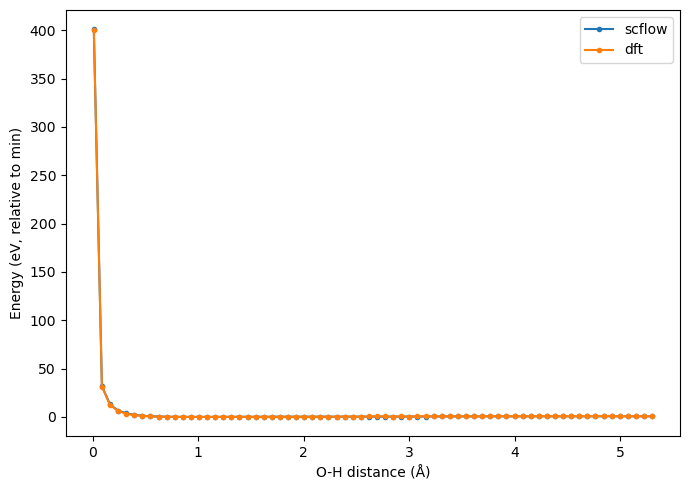

Saved combined plot to /home/yoonho/MDsim/dissociation_test/ethanol_dissociation_curves_all.png


In [15]:
#!/usr/bin/env python
"""
Compute O–H bond dissociation curves for ethanol using trained models (eSEN, DimeNet, SchNet)
and optionally DFT (psi4). Outputs energies (relative to each curve minimum) and a plot.

This version is adapted for Jupyter notebook:
- No argparse / __main__
- You set input paths and options as variables below.
"""
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import torch

# -----------------------------
# User configuration (edit here)
# -----------------------------
# Path to RMD17 ethanol HDF5 file
h5_path = Path("/home/yoonho/rmd_ham_data/rmd-ethanol/data.h5")

# Output directory for .npy and plots
out_dir = Path("/root/25DFT/QHFlow/src/md/test_script/outputs")

# Distance range (Å) and number of points
dist_min = 0.01
# dist_max = 6.0
dist_max = 5.3
n_points = 70

# Models to use
models = ["scflow", "dft"]  # subset: e.g. ["esen"]

# Whether to compute DFT with psi4
compute_dft = False  # True / False

# Per-model GPU mapping, e.g. {"esen": "4", "dimenet": "5", "schnet": "6"}
gpu_map = None  # or dict, e.g. {"esen": "4", "dimenet": "5", "schnet": "6"}

# Plot prefix
plot_prefix = "ethanol_dissociation_curves"
# -----------------------------


# Ensure local imports work (adapted to your project layout)
# NOTE: In a notebook, __file__ is not defined; use project root directly.
ROOT = Path("/root/25DFT/QHFlow/src").resolve()
sys.path.insert(0, str(ROOT))

# from mdsim.md.ase_utils import OCPCalculator, ESENCalculator  # type: ignore
from ase import Atoms


def load_base_atoms(h5_path: Path) -> Atoms:
    """Load atomic_numbers and positions from sample_0 of RMD17 HDF5."""
    with h5py.File(h5_path, "r") as f:
        idx = 0
        grp = f[f"sample_{idx}"]
        Z = grp["atomic_numbers"][:].astype(int)
        pos = grp["positions"][:]
    atoms = Atoms(numbers=Z, positions=pos)
    return atoms


def find_oh_pair(atoms: Atoms):
    """Return indices (iO, iH) where O is atomic number 8 and H is closest hydrogen to that O."""
    O_indices = [i for i, z in enumerate(atoms.get_atomic_numbers()) if z == 8]
    H_indices = [i for i, z in enumerate(atoms.get_atomic_numbers()) if z == 1]
    assert O_indices and H_indices, "No O/H atoms found"
    iO = O_indices[0]
    distances = [atoms.get_distance(iO, h) for h in H_indices]
    iH = H_indices[int(np.argmin(distances))]
    return iO, iH


def set_oh_distance(atoms: Atoms, iO: int, iH: int, target: float):
    """Move H along the O->H vector to achieve target distance (Å)."""
    atoms = atoms.copy()
    vec = atoms.positions[iH] - atoms.positions[iO]
    curr = np.linalg.norm(vec)
    if curr < 1e-8:
        return atoms
    delta = (vec / curr) * (target - curr)
    atoms.positions[iH] += delta
    return atoms


def run_curve_single(distances, calculator, atoms: Atoms, iO: int, iH: int):
    vals = []
    for d in distances:
        print(d)
        geom = set_oh_distance(atoms, iO, iH, d)
        geom.calc = calculator
        vals.append(geom.get_potential_energy())
        print(vals[-1])
    return np.array(vals)


def maybe_dft(distances, atoms: Atoms, iO: int, iH: int):
    try:
        import psi4
    except ImportError:
        print("psi4 not available; skipping DFT.")
        return None

    psi4.set_options({"reference": "uks", "dft_spherical_points": 302, "dft_radial_points": 75})
    psi4.set_memory("4 GB")
    psi4.core.set_num_threads(4)

    energies = []
    Z = atoms.get_atomic_numbers()
    for d in distances:
        geom = set_oh_distance(atoms, iO, iH, d)
        lines = ["0 1"]
        for z, (x, y, zpos) in zip(Z, geom.positions):
            lines.append(f"{int(z)}   {x:.6f}  {y:.6f}  {zpos:.6f}")
        mol_str = "\n".join(lines)
        mol = psi4.geometry(mol_str)
        try:
            e_h, _ = psi4.energy("pbe/def2-svp", return_wfn=True)
            energies.append(e_h * 27.2114)  # Hartree -> eV
        except Exception as exc:
            print(f"DFT failed at d={d:.2f}: {exc}")
            energies.append(np.nan)
    return np.array(energies)


def shift_to_min(arr):
    return arr - np.nanmin(arr)


# ============================
# Main execution in notebook
# ============================

# Prepare output directory
out_dir.mkdir(parents=True, exist_ok=True)

atoms = Atoms(numbers=sample_ethanol_atoms, positions=sample_ethanol_coords, cell=np.eye(3), pbc=False)
iO, iH = find_oh_pair(atoms)
print(f"Using O index {iO}, H index {iH}, initial d={atoms.get_distance(iO, iH):.3f} Å")

distances = np.linspace(dist_min, dist_max, n_points)

# Save original CUDA_VISIBLE_DEVICES
orig_cuda_env = os.environ.get("CUDA_VISIBLE_DEVICES", None)


def set_gpu(label):
    if gpu_map is None:
        # restore original if not using mapping
        if orig_cuda_env is None:
            os.environ.pop("CUDA_VISIBLE_DEVICES", None)
        else:
            os.environ["CUDA_VISIBLE_DEVICES"] = orig_cuda_env
        return

    dev = gpu_map.get(label, None)
    if dev is not None:
        os.environ["CUDA_VISIBLE_DEVICES"] = str(dev)
        try:
            torch.cuda.set_device(0)
        except Exception:
            pass
    else:
        # restore original if not using mapping
        if orig_cuda_env is None:
            os.environ.pop("CUDA_VISIBLE_DEVICES", None)
        else:
            os.environ["CUDA_VISIBLE_DEVICES"] = orig_cuda_env


energies = {}

# Build and run per-model sequentially on mapped GPU
for mdl in models:
    set_gpu(mdl)
    if mdl == "esen":
        esen_dir = "/home/yoonho/MDsim/trained_models/esen_rmd17_ethanol_re"
        calc = ESENCalculator(
            model_dir=esen_dir,
            device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        )
    elif mdl == "dimenet":
        dim_dir = "/home/yoonho/MDsim/trained_models/rmd17_dimenet_re_norm_false/rmd-ethanol_10k_dimenet_re_norm_false"
        calc = OCPCalculator(
            config_yml=f"{dim_dir}/checkpoints/config.yml",
            checkpoint=f"{dim_dir}/checkpoints/best_checkpoint.pt",
            test_data_src=None,
        )
    elif mdl == "schnet":
        sch_dir = "/home/yoonho/MDsim/trained_models/rmd17_schnet_re_norm_false/rmd-ethanol_10k_schnet_re_norm_false"
        calc = OCPCalculator(
            config_yml=f"{sch_dir}/checkpoints/config.yml",
            checkpoint=f"{sch_dir}/checkpoints/best_checkpoint.pt",
            test_data_src=None,
        )
    elif mdl == "scflow":
        cur_ckpt = "/root/25DFT/QHFlow/src/outputs/ethanol/QHFlow_so2_v5_1_middle-ethanol/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"
        calc = md.scflow_calculator.SCFlowRKSCalculator()
        calc.set_model(cur_ckpt, units="ang", model_length_unit="bohr")
        calc.model.max_radius=20.0
        calc.model.model.node_attr_backbone.cutoff=10.0
    elif mdl == "dft":
        calc = md.scflow_calculator.RKSCalculator()
    else:
        print(f"Unknown model: {mdl}, skipping.")
        continue

    print(f"Running model: {mdl}")
    energies[mdl] = run_curve_single(distances, calc, atoms, iO, iH)
    del calc
    torch.cuda.empty_cache()

# restore original env
if orig_cuda_env is None:
    os.environ.pop("CUDA_VISIBLE_DEVICES", None)
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = orig_cuda_env

# DFT if requested
if compute_dft:
    print("Running DFT (psi4)...")
    dft_E = maybe_dft(distances, atoms, iO, iH)
    energies["dft"] = dft_E

# Save raw energies per model and plots
for name, arr in energies.items():
    np.save(out_dir / f"ethanol_{name}_energies.npy", arr)
    plt.figure(figsize=(7, 5))
    rel = shift_to_min(arr)
    plt.plot(distances, rel, marker="o", ms=3, label=name)
    plt.xlabel("O-H distance (Å)")
    plt.ylabel("Energy (eV, relative to min)")
    plt.legend()
    plt.tight_layout()
    out_plot = out_dir / f"{plot_prefix}_{name}.png"
    plt.savefig(out_plot, dpi=200)
    plt.close()
    print(f"Saved plot to {out_plot}")

    plt.figure(figsize=(7, 5))
    rel = shift_to_min(arr)
    plt.plot(distances[2:], rel[2:], marker="o", ms=3, label=name)
    plt.xlabel("O-H distance (Å)")
    plt.ylabel("Energy (eV, relative to min)")
    plt.legend()
    plt.tight_layout()
    out_plot = out_dir / f"{plot_prefix}_{name}_exclude.png"
    plt.savefig(out_plot, dpi=200)
    plt.close()
    print(f"Saved plot to {out_plot}")

# Combined plot
plt.figure(figsize=(7, 5))
for name, arr in energies.items():
    rel = shift_to_min(arr)
    plt.plot(distances, rel, marker="o", ms=3, label=name)
plt.xlabel("O-H distance (Å)")
plt.ylabel("Energy (eV, relative to min)")
plt.legend()
plt.tight_layout()
combined = out_dir / f"{plot_prefix}_all.png"
plt.savefig(combined, dpi=200)
plt.show()
print(f"Saved combined plot to {combined}")

In [18]:
out_dir = Path("/root/25DFT/QHFlow/src/md/test_script/outputs_no_gpu")


for name, arr in energies.items():
    if name == "dft":
        name = "dft_no_gpu"
    np.save(out_dir / f"ethanol_{name}_energies.npy", arr)
    plt.figure(figsize=(7, 5))
    rel = shift_to_min(arr)
    plt.plot(distances, rel, marker="o", ms=3, label=name)
    plt.xlabel("O-H distance (Å)")
    plt.ylabel("Energy (eV, relative to min)")
    plt.legend()
    plt.tight_layout()
    out_plot = out_dir / f"{plot_prefix}_{name}.png"
    plt.savefig(out_plot, dpi=200)
    plt.close()
    print(f"Saved plot to {out_plot}")

    plt.figure(figsize=(7, 5))
    rel = shift_to_min(arr)
    plt.plot(distances[2:], rel[2:], marker="o", ms=3, label=name)
    plt.xlabel("O-H distance (Å)")
    plt.ylabel("Energy (eV, relative to min)")
    plt.legend()
    plt.tight_layout()
    out_plot = out_dir / f"{plot_prefix}_{name}_exclude.png"
    plt.savefig(out_plot, dpi=200)
    plt.close()
    print(f"Saved plot to {out_plot}")


Saved plot to /root/25DFT/QHFlow/src/md/test_script/outputs_no_gpu/ethanol_dissociation_curves_scflow.png
Saved plot to /root/25DFT/QHFlow/src/md/test_script/outputs_no_gpu/ethanol_dissociation_curves_scflow_exclude.png
Saved plot to /root/25DFT/QHFlow/src/md/test_script/outputs_no_gpu/ethanol_dissociation_curves_dft_no_gpu.png
Saved plot to /root/25DFT/QHFlow/src/md/test_script/outputs_no_gpu/ethanol_dissociation_curves_dft_no_gpu_exclude.png


In [ ]:
atoms.calc = calc

In [19]:
cur_ckpt = "/root/25DFT/QHFlow/src/outputs/ethanol/QHFlow_so2_v5_1_middle-ethanol/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"
calc = md.scflow_calculator.SCFlowRKSCalculator()
calc.set_model(cur_ckpt, units="ang", model_length_unit="bohr")
calc.model.max_radius=20.0
calc.model.model.node_attr_backbone.cutoff=10.0

[autoreload of numpy.core.multiarray failed: Traceback (most recent call last):
  File "/root/miniforge3/envs/pyscf2/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/root/miniforge3/envs/pyscf2/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/root/miniforge3/envs/pyscf2/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/root/miniforge3/envs/pyscf2/lib/python3.12/site-packages/numpy/core/multiarray.py", line 1, in <module>
    from numpy._core import multiarray
  File "/root/miniforge3/envs/pyscf2/lib/python3.12/site-packages/numpy/_core/

INFO     [__init__.py:100] >> model_args: {'in_node_features': 1, 'sh_lmax': 4, 'hidden_size': 128,                
         'bottle_hidden_size': 32, 'num_gnn_layers': 3, 'max_radius': 15, 'num_nodes': 10, 'radius_embed_dim': 16, 
         'max_T': 15, 'use_block_S': False, 'use_block_H': False, 'ham_dim': 24, 'ham_hidden': 288, 'dataset_type':
         'qh9', 'num_ham_gnn_layers': 2}

Setting device to cuda


INFO     [base_module.py:128] >> use_init_hamiltonian: False

INFO     [base_module.py:129] >> use_init_hamiltonian_residue: True

INFO     [base_module.py:130] >> ema_start_epoch: -1

INFO     [base_module.py:131] >> qh9: False

INFO     [base_module.py:132] >> test_mode: test

INFO     [flow_module.py:211] >> init_p0_type: expand

model trained on dataset:  ethanol
ode_steps: 1
